Running AlievPanfilov on [100, 10] mesh: 100%|██████████| 20000/20000 [00:00<00:00, 26824.10it/s]


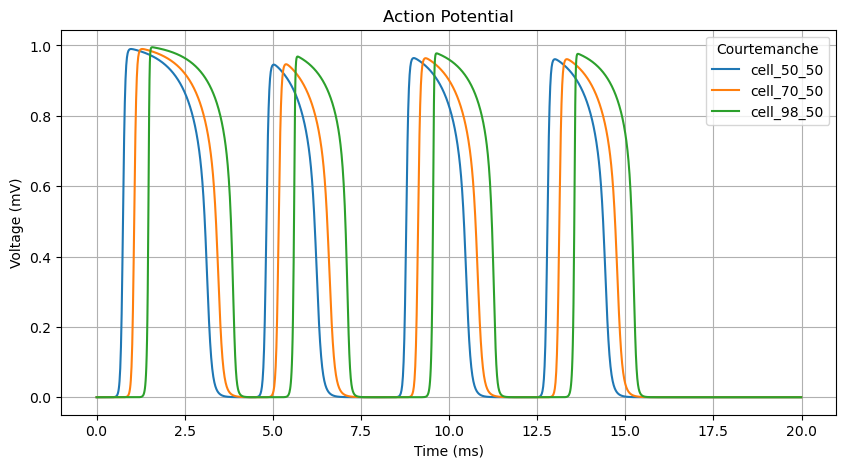

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave.gridywave as fw

n = 100
m = 10

tissue = fw.CardiacTissueGrid([n, m])

# create model object and set up parameters
courtemanche = fw.Courtemanche()
# Here, we increase g_Kur by a factor of 3 to better match physiological AP shape
# with a visible plateau and realistic repolarization.
# courtemanche.gkur_coeff *= 3
courtemanche.gkur_coeff *= 0.5
courtemanche.gto *= 0.5
courtemanche.gcal *= 0.3

# set up stimulation parameters
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageGridCoord(0, 1, 0, 5, 0, m))
stim_sequence.add_stim(fw.StimVoltageGridCoord(40, 1, 0, 5, 0, m))
stim_sequence.add_stim(fw.StimVoltageGridCoord(80, 1, 0, 5, 0, m))
stim_sequence.add_stim(fw.StimVoltageGridCoord(120, 1, 0, 5, 0, m))

action_pot_tracker = fw.ActionPotentialGridTracker()
# to specify the mesh node under the measuring - use the cell_ind field:
# eather list or list of lists can be used
action_pot_tracker.cell_ind = [[50, 5], [70, 5], [98, 5]]
action_pot_tracker.step = 10

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(action_pot_tracker)

simulation = fw.CardiacGridSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 200
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.AlievPanfilov()
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

# plot the action potential
plt.figure(figsize=(10, 5))
time = np.arange(len(action_pot_tracker.output)) * simulation.dt
plt.plot(time, action_pot_tracker.output[:, 0], label="cell_50_50")
plt.plot(time, action_pot_tracker.output[:, 1], label="cell_70_50")
plt.plot(time, action_pot_tracker.output[:, 2], label="cell_98_50")
plt.legend(title='Courtemanche')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Action Potential')
plt.grid()
plt.show()


0.0 0.32
0.0 0.32
0.36 1.0
0.0 0.32
0.0 0.32


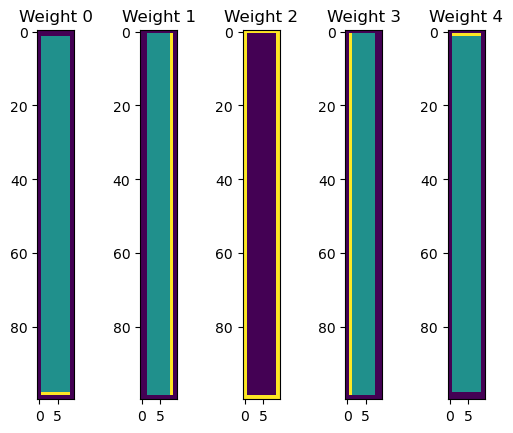

In [23]:
fig, axs = plt.subplots(ncols=5)
for i in range(5):
    w = simulation.diffusion_model.weights[:, :, i]
    print(w.min(), w.max())
    axs[i].imshow(w)
    axs[i].set_title(f"Weight {i}")
plt.show()
